### **MVTec AD Dataset**

**MVTec AD** is a dataset for benchmarking anomaly detection methods with a focus on **industrial inspection**.

It contains over **5000 high-resolution images** divided into fifteen different object and texture categories. Each category comprises:

* A set of **defect-free training images**.
* A **test set** of images with various kinds of defects as well as images without defects.

For this project purposes, only the **capsule** subset will be used:

| GOOD Sample | ANOMALY Sample |
| :---: | :---: |
| <img src="reports/figures/capsule_good.png" width="350"> | <img src="reports/figures/capsule_poke.png" width="350"> |

**Dataset structure:**

* 'train', which contains the (defect-free) training images
* 'test', which contains the test images
* 'ground_truth', which contains the pixel-precise annotations of anomalous regions

_Dataset official link: https://www.mvtec.com/company/research/datasets/mvtec-ad_

In [1]:
import os
import cv2
import mlflow
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob

In [2]:
def process_images(path, label, img_size):
    """Loads and processes images from a given directory.
        Args: 
            path: str, path to the directory containing images
            label: int, label to assign to all images in this directory
            img_size: tuple, desired size to resize images (width, height)
            
        Returns:
            data: list of processed images
            labels: list of labels corresponding to each image
    """

    image_files = glob(os.path.join(path, "*.png"))
    data = []
    labels = []

    print(f"Loading {len(image_files)} from: {path}")
    
    for image in image_files:
        img = cv2.imread(image) # Load image
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) # Transform into gray scale
        img_resized = cv2.resize(img_gray, img_size) # Resize the image

        data.append(img_resized) # Store the processed image
        labels.append(label)

    return data, labels

Loading 219 from: data/raw/capsule/train/good
Loading 23 from: data/raw/capsule/test/crack
Loading 0 from: data/raw/capsule/test/.DS_Store
Loading 23 from: data/raw/capsule/test/scratch
Loading 21 from: data/raw/capsule/test/poke
Loading 23 from: data/raw/capsule/test/good
Loading 22 from: data/raw/capsule/test/faulty_imprint
Loading 20 from: data/raw/capsule/test/squeeze

Training data shape (good only): (219, 128, 128)
Validation data shape (mixed): (66, 128, 128)
Test data shape (mixed): (66, 128, 128)

 Sample images after processing:


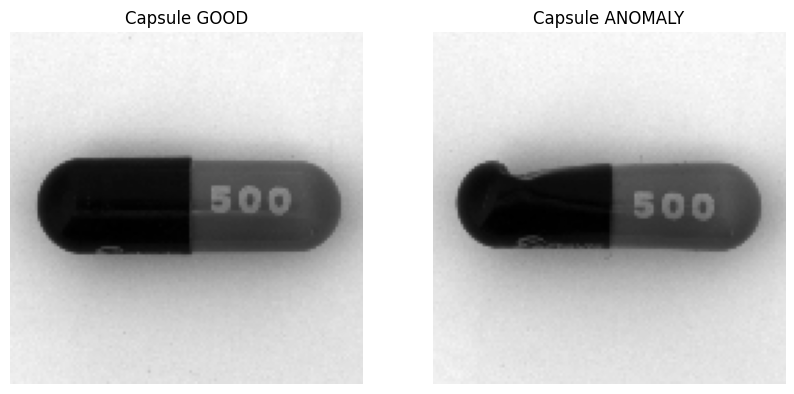

In [3]:
from sklearn.model_selection import train_test_split

DATASET_PATH = "data/raw/capsule"
IMG_SIZE = (128, 128) # Final size of images

#### --- LOADING TRAINING DATA (GOOD ONLY) --- ####
train_path = os.path.join(DATASET_PATH, "train", "good")
X_train, y_train = process_images(train_path, label=0, img_size=IMG_SIZE)

#### --- LOADING EVAL POOL (MIXED: GOOD + ANOMALY) --- ####
test_root_path = os.path.join(DATASET_PATH, "test")
subfolders = os.listdir(test_root_path)

X_eval = []
y_eval = []

for folder in subfolders:
    folder_path = os.path.join(test_root_path, folder)

    label = 0 if folder == "good" else 1 # Label 1 is for any anomaly

    images, labels = process_images(folder_path, label=label, img_size=IMG_SIZE)

    X_eval.extend(images)
    y_eval.extend(labels)

# Convert into numpy arrays:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_eval = np.array(X_eval)
y_eval = np.array(y_eval)

#### --- SPLIT EVAL POOL INTO VALIDATION/TEST --- ####
X_val, X_test, y_val, y_test = train_test_split(
    X_eval,
    y_eval,
    test_size=0.5,
    random_state=42,
    stratify=y_eval
    )

print(f"\nTraining data shape (good only): {X_train.shape}")
print(f"Validation data shape (mixed): {X_val.shape}")
print(f"Test data shape (mixed): {X_test.shape}")

print("\n Sample images after processing:")

# Show sample images:
plt.figure(figsize=(10, 5))

# GOOD image from train:
plt.subplot(1, 2, 1)
plt.imshow(X_train[0], cmap='gray')
plt.title("Capsule GOOD")
plt.axis('off')

# ANOMALY image from validation set:
anomaly_idx = np.where(y_val == 1)[0][47] # Index of anomaly

plt.subplot(1, 2, 2)
plt.imshow(X_val[anomaly_idx], cmap='gray')
plt.title("Capsule ANOMALY")
plt.axis('off')

plt.show()

### HOG (Histogram of Oriented Gradients) Explained

**1. What is it?**
HOG is a feature extraction technique used in computer vision. Instead of looking at the specific color of pixels, it looks at the **direction and intensity of edges** (gradients). It divides the image into small grids and counts how many "lines" point in different directions (vertical, horizontal, diagonal).

**2. Why do we need it here?**
We are using "Classic Machine Learning" (like Isolation Forest), not Deep Learning.
* **Raw pixels are too noisy:** A slight change in lighting or position changes every pixel value, confusing the model.
* **Dimensionality:** A 128x128 image has 16,384 features. Raw pixels are inefficient.
* **HOG extracts structure:** It converts the image into a compact numerical vector that describes the **shape and texture**, which is what matters for detecting defects.

**3. How it applies to Capsules:**
* **Normal Capsule:** Has smooth curves and consistent printed text. HOG generates a predictable pattern of gradients.
* **Defective Capsule (Crack/Scratch):** A crack creates a sharp, jagged edge where there should be a smooth surface. HOG detects this **sudden change in gradient intensity and direction**, creating a numerical "scar" in the data vector that the Anomaly Detection model can easily flag.

In [4]:
from skimage.feature import hog
from skimage import exposure

def extract_hog_features(images):
    """Takes a list/array of images and returns their HOG features.
        Args:
            - images: list/array of images (2D arrays)
            
        Returns:
            - hog_features: array of HOG features for each image
            - hog_images: array of HOG images for visualization
    """
    hog_features = []
    hog_images = []

    print("Extracting HOG Features...")

    for image in images:
        feat, hog_image = hog(
            image,
            orientations=9, # Edge directions
            pixels_per_cell=(8, 8), # Size of the grid
            cells_per_block=(2, 2), # Block normalization
            visualize=True,
            block_norm='L2-Hys'
        )

        hog_features.append(feat)
        hog_images.append(hog_image)

    return np.array(hog_features), np.array(hog_images)


In [5]:
#### --- APPLY HOG TO THE DATASET --- ####
X_train_hog, X_train_hog_imgs = extract_hog_features(X_train)
X_val_hog, X_val_hog_imgs = extract_hog_features(X_val)
X_test_hog, X_test_hog_imgs = extract_hog_features(X_test)

print(f"\n --- EXTRACTION RESULT ---")
print(f"Original image: {IMG_SIZE} pixels")
print(f"HOG Feature Vector: {X_train_hog.shape[1]} numerical values")
print(f"Validation HOG shape: {X_val_hog.shape}")
print(f"Test HOG shape: {X_test_hog.shape}")

Extracting HOG Features...
Extracting HOG Features...
Extracting HOG Features...

 --- EXTRACTION RESULT ---
Original image: (128, 128) pixels
HOG Feature Vector: 8100 numerical values
Validation HOG shape: (66, 8100)
Test HOG shape: (66, 8100)


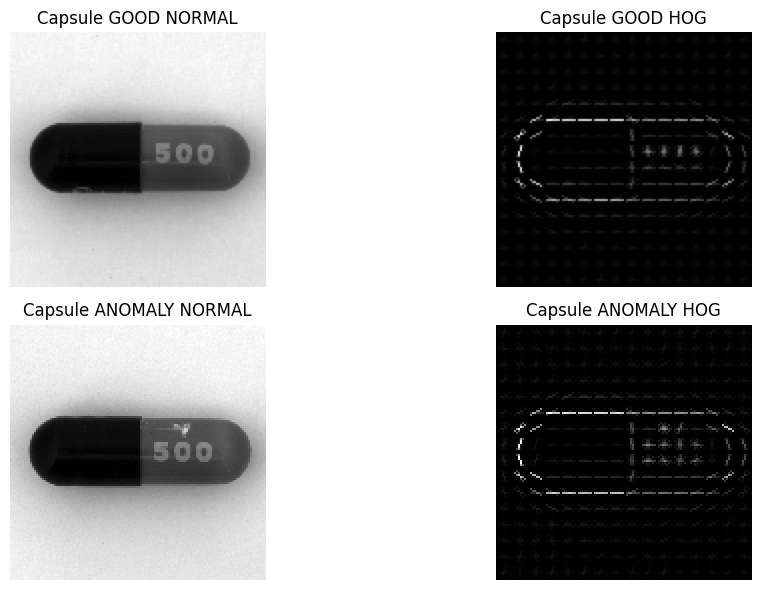

In [6]:
#### --- VISUALIZE HOG --- ####
plt.figure(figsize=(12, 6))

# ANOMALY image index: 
anomaly_idx = np.where(y_test == 1)[0][40] # Index of anomaly image

# GOOD image normal:
plt.subplot(2, 2, 1)
plt.imshow(X_train[0], cmap='gray')
plt.title("Capsule GOOD NORMAL")
plt.axis('off')

# GOOD image HOG:
plt.subplot(2, 2, 2)
plt.imshow(X_train_hog_imgs[0], cmap='gray')
plt.title("Capsule GOOD HOG")
plt.axis('off')

# ANOMALY image normal:
plt.subplot(2, 2, 3)
plt.imshow(X_test[anomaly_idx], cmap='gray')
plt.title("Capsule ANOMALY NORMAL")
plt.axis('off')

# ANOMALY image HOG:
plt.subplot(2, 2, 4)
plt.imshow(X_test_hog_imgs[anomaly_idx], cmap='gray')
plt.title("Capsule ANOMALY HOG")
plt.axis('off')

plt.tight_layout()
plt.show()

### Supervised Baselines (added)

The following supervised classifiers are added as baselines. They are trained on a standard supervised split derived from the mixed evaluation pool (validation+test). For each model we run a small grid search, pick a threshold on the validation fold to meet a target recall when possible, and report Classification Report, Confusion Matrix and ROC-AUC.


--- Running supervised baseline: LogisticRegression ---
Best candidate for LogisticRegression: {'params': {'C': 0.01}, 'threshold': 0.8792094461249573, 'method': 'target_recall', 'val_macro_f1': 0.6783625730994152, 'val_balanced_acc': 0.6481481481481481}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       0.67      0.33      0.44        12
           1       0.87      0.96      0.91        54

    accuracy                           0.85        66
   macro avg       0.77      0.65      0.68        66
weighted avg       0.83      0.85      0.83        66

ROC AUC: 0.7469


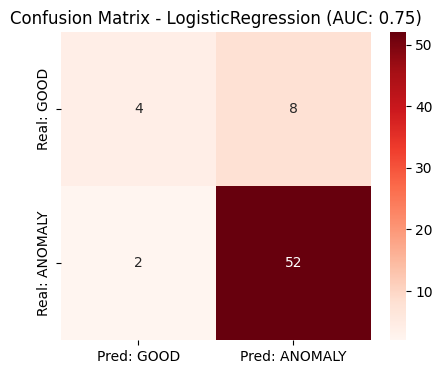


--- Running supervised baseline: LDA ---
Best candidate for LDA: {'params': {'solver': 'svd'}, 'threshold': 0.8179141024430463, 'method': 'target_recall', 'val_macro_f1': 0.5732758620689655, 'val_balanced_acc': 0.5648148148148148}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       0.50      0.17      0.25        12
           1       0.84      0.96      0.90        54

    accuracy                           0.82        66
   macro avg       0.67      0.56      0.57        66
weighted avg       0.78      0.82      0.78        66

ROC AUC: 0.7284


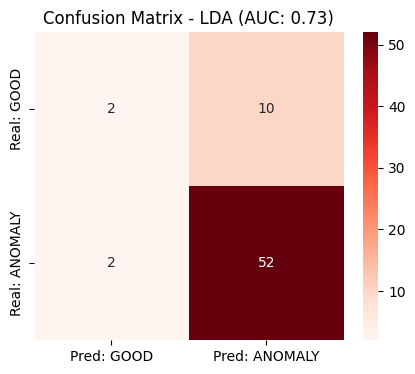


--- Running supervised baseline: SVC ---
Best candidate for SVC: {'params': {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale'}, 'threshold': 0.34381508101031716, 'method': 'target_recall', 'val_macro_f1': 0.5732758620689655, 'val_balanced_acc': 0.5648148148148148}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       0.50      0.17      0.25        12
           1       0.84      0.96      0.90        54

    accuracy                           0.82        66
   macro avg       0.67      0.56      0.57        66
weighted avg       0.78      0.82      0.78        66

ROC AUC: 0.7454


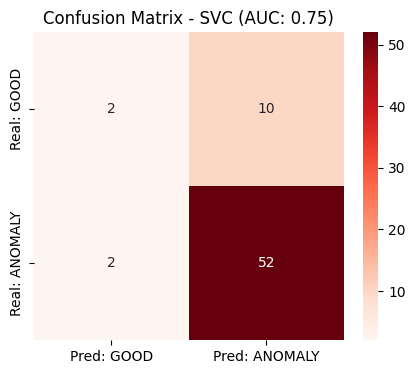


--- Running supervised baseline: MLP ---
Best candidate for MLP: {'params': {'hidden_layer_sizes': (100,), 'alpha': 0.001}, 'threshold': 0.001725509023396759, 'method': 'target_recall', 'val_macro_f1': 0.5732758620689655, 'val_balanced_acc': 0.5648148148148148}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       1.00      0.08      0.15        12
           1       0.83      1.00      0.91        54

    accuracy                           0.83        66
   macro avg       0.92      0.54      0.53        66
weighted avg       0.86      0.83      0.77        66

ROC AUC: 0.7299


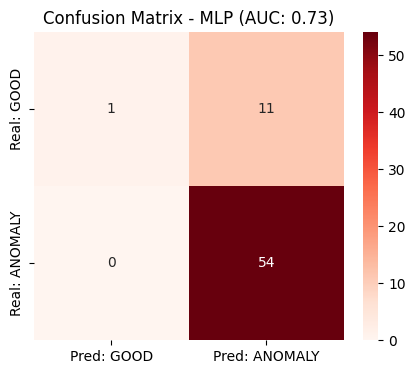


--- Running supervised baseline: DecisionTree ---
Best candidate for DecisionTree: {'params': {'max_depth': 5, 'min_samples_split': 2}, 'threshold': 0.0, 'method': 'target_recall', 'val_macro_f1': 0.45, 'val_balanced_acc': 0.5}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.82      1.00      0.90        54

    accuracy                           0.82        66
   macro avg       0.41      0.50      0.45        66
weighted avg       0.67      0.82      0.74        66

ROC AUC: 0.5370


/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


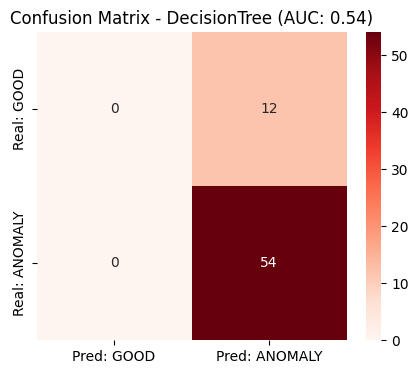


--- Running supervised baseline: BaggingTree ---
Best candidate for BaggingTree: {'params': {'n_estimators': 10}, 'threshold': 0.4, 'method': 'target_recall', 'val_macro_f1': 0.5863247863247864, 'val_balanced_acc': 0.5740740740740741}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       1.00      0.08      0.15        12
           1       0.83      1.00      0.91        54

    accuracy                           0.83        66
   macro avg       0.92      0.54      0.53        66
weighted avg       0.86      0.83      0.77        66

ROC AUC: 0.6474


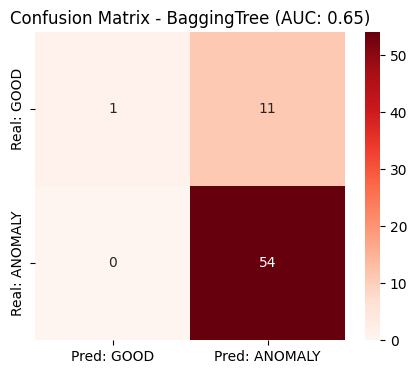


--- Running supervised baseline: RandomForest ---
Best candidate for RandomForest: {'params': {'n_estimators': 50, 'max_depth': None}, 'threshold': 0.7, 'method': 'target_recall', 'val_macro_f1': 0.5732758620689655, 'val_balanced_acc': 0.5648148148148148}

Classification report (validation holdout):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.82      0.98      0.89        54

    accuracy                           0.80        66
   macro avg       0.41      0.49      0.45        66
weighted avg       0.67      0.80      0.73        66

ROC AUC: 0.4938


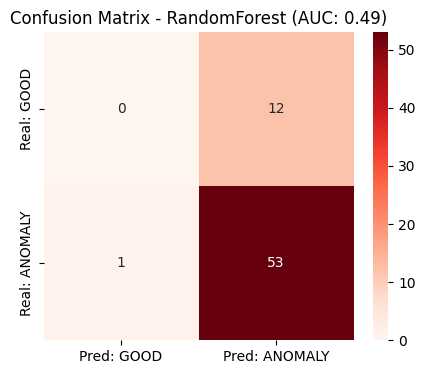

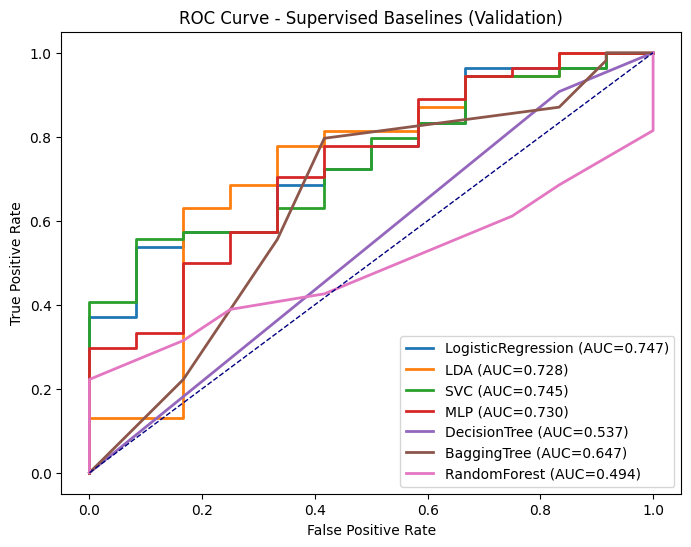

Supervised baselines run finished


In [7]:
# Parameters:
EXPERIMENT_NAME = "anomaly_capsule_detection"
RUN_NAME = "Try: Baseline Supervised Models"

# Prepare a supervised training pool from the mixed evaluation sets (X_val_hog, X_test_hog)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, balanced_accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import mlflow
import seaborn as sns
import os

# Create supervised pool (mixed labeled data) and stratified split for supervised training/holdout
X_super_pool = np.vstack([X_val_hog, X_test_hog])
y_super_pool = np.concatenate([y_val, y_test])
# Split into supervised train/validation (50/50 of the pool) with stratification
X_sup_train, X_sup_val, y_sup_train, y_sup_val = train_test_split(X_super_pool, y_super_pool, test_size=0.5, random_state=42, stratify=y_super_pool)

# Scale features once for supervised models
sup_scaler = StandardScaler()
X_sup_train_s = sup_scaler.fit_transform(X_sup_train)
X_sup_val_s = sup_scaler.transform(X_sup_val)

# Target recall used for threshold calibration on the supervised validation split
HP_TARGET_RECALL_SUP = 0.95

# Utility to extract anomaly score from a trained estimator
def get_scores(estimator, X):
    # prefer predict_proba for probability estimates, then decision_function, else use predict() as 0/1 scores
    if hasattr(estimator, 'predict_proba'):
        try:
            return estimator.predict_proba(X)[:, 1]
        except Exception:
            pass
    if hasattr(estimator, 'decision_function'):
        return estimator.decision_function(X)
    # fallback to binary predictions (0/1) as scores
    return estimator.predict(X)

# Function to select threshold on validation to meet target_recall or maximize F1 (same technique used elsewhere)
def select_threshold(y_true, scores, target_recall=HP_TARGET_RECALL_SUP):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    try:
        idxs = np.where(recall >= target_recall)[0]
        if len(idxs) > 0:
            idx = idxs[-1]
            best_threshold = thresholds[idx] if idx < len(thresholds) else np.percentile(scores, 5)
            method = 'target_recall'
        else:
            raise IndexError
    except Exception:
        # fallback: maximize F1 over candidate thresholds
        f1s = []
        thr_candidates = np.concatenate(([np.percentile(scores, p) for p in range(1,100,2)], thresholds))
        thr_candidates = np.unique(thr_candidates)
        for thr in thr_candidates:
            y_pred = (scores >= thr).astype(int)
            f1s.append(f1_score(y_true, y_pred, zero_division=0))
        best_idx = np.nanargmax(f1s)
        best_threshold = thr_candidates[best_idx]
        method = 'max_f1'
    return float(best_threshold), method

# Supervised classifiers and small grids
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

models_to_run = [
    ('LogisticRegression', LogisticRegression(max_iter=1000, solver='liblinear'), {'C': [0.01, 0.1, 1, 10]}),
    ('LDA', LinearDiscriminantAnalysis(), {'solver': ['svd']}),
    ('SVC', SVC(probability=True), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale','auto']}),
    ('MLP', MLPClassifier(max_iter=500), {'hidden_layer_sizes': [(50,), (100,)], 'alpha': [1e-4, 1e-3]}),
    ('DecisionTree', DecisionTreeClassifier(), {'max_depth': [5, 10, None], 'min_samples_split': [2,5]}),
    ('BaggingTree', BaggingClassifier(estimator=DecisionTreeClassifier(), n_jobs=-1), {'n_estimators': [10, 50]}),
    ('RandomForest', RandomForestClassifier(n_jobs=-1), {'n_estimators': [50, 100], 'max_depth': [None, 10]})
]

# Run simple grid search (iterative) and evaluate on supervised validation split
sup_results = []
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME):
    for name, base_est, grid in models_to_run:
        with mlflow.start_run(run_name=f'Supervised - {name}', nested=True):
            print(f'\n--- Running supervised baseline: {name} ---')
            mlflow.log_param('model_name', name)

            best_candidate = None
            candidate_records = []

            # Build parameter product manually to avoid heavy GridSearchCV defaults
            import itertools
            keys = list(grid.keys()) if isinstance(grid, dict) else []
            values = [grid[k] for k in keys] if keys else [[]]
            param_products = list(itertools.product(*values)) if keys else [()]

            for prod in param_products:
                params = dict(zip(keys, prod)) if keys else {}
                clf = base_est.__class__(**(params if isinstance(params, dict) else {})) if keys else base_est
                # For estimators where base_est.__class__(**kwargs) fails (e.g., Bagging with base_estimator), fallback to setting params via set_params
                try:
                    clf.set_params(**params)
                except Exception:
                    pass

                # Fit on supervised train
                try:
                    clf.fit(X_sup_train_s, y_sup_train)
                except Exception as e:
                    print('Fit failed for', name, params, '->', e)
                    continue

                # Get validation scores (higher -> more likely anomaly=1)
                val_scores = get_scores(clf, X_sup_val_s)
                # Ensure numeric array
                val_scores = np.array(val_scores).ravel()

                # Select threshold
                thr, method = select_threshold(y_sup_val, val_scores)
                y_val_pred = (val_scores >= thr).astype(int)
                report = classification_report(y_sup_val, y_val_pred, output_dict=True, zero_division=0)
                macro_f1 = float(report['macro avg']['f1-score'])
                bal_acc = float(balanced_accuracy_score(y_sup_val, y_val_pred))

                candidate_records.append({'params': params, 'threshold': thr, 'method': method, 'val_macro_f1': macro_f1, 'val_balanced_acc': bal_acc})

            # Choose best candidate
            if len(candidate_records) == 0:
                print('No successful candidates for', name)
                continue
            candidate_records = sorted(candidate_records, key=lambda r: (r['val_macro_f1'], r['val_balanced_acc']), reverse=True)
            best = candidate_records[0]
            print(f'Best candidate for {name}:', best)
            mlflow.log_param(f'{name}_grid', grid)
            mlflow.log_param(f'{name}_chosen_params', best['params'])
            mlflow.log_param(f'{name}_chosen_threshold', best['threshold'])

            # Refit best model on full supervised train (train split)
            final_clf = base_est.__class__(**(best['params'] if isinstance(best['params'], dict) else {})) if keys else base_est
            try:
                final_clf.set_params(**(best['params'] if isinstance(best['params'], dict) else {}))
            except Exception:
                pass
            final_clf.fit(X_sup_train_s, y_sup_train)
            final_scores = get_scores(final_clf, X_sup_val_s)
            final_scores = np.array(final_scores).ravel()
            y_final_pred = (final_scores >= best['threshold']).astype(int)

            # Metrics and artifacts
            report_str = classification_report(y_sup_val, y_final_pred)
            print('\nClassification report (validation holdout):')
            print(report_str)
            auc = roc_auc_score(y_sup_val, final_scores)
            print(f'ROC AUC: {auc:.4f}')

            # Confusion matrix plot
            cm = confusion_matrix(y_sup_val, y_final_pred)
            fig_cm, ax = plt.subplots(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Pred: GOOD','Pred: ANOMALY'], yticklabels=['Real: GOOD','Real: ANOMALY'], ax=ax)
            ax.set_title(f'Confusion Matrix - {name} (AUC: {auc:.2f})')
            cm_temp_path = f'reports/figures/cm_{name.lower().replace(" ","_")}_val.png'
            fig_cm.savefig(cm_temp_path)
            mlflow.log_artifact(cm_temp_path)
            os.remove(cm_temp_path)
            plt.show()

            # Log metrics
            metrics_to_log = {'accuracy': float(report['accuracy']) if 'accuracy' in report else 0.0, 'macro_avg_f1': best['val_macro_f1'], 'roc_auc': float(auc)}
            mlflow.log_metrics(metrics_to_log)

            # Save ROC curve data for collective plot
            fpr, tpr, _ = roc_curve(y_sup_val, final_scores)

            sup_results.append({'name': name, 'best': best, 'auc': float(auc), 'fpr': fpr, 'tpr': tpr})

    # Combined ROC for all supervised baselines (validation set)
    if len(sup_results) > 0:
        fig_all, ax_all = plt.subplots(figsize=(8,6))
        for r in sup_results:
            ax_all.plot(r['fpr'], r['tpr'], lw=2, label=f"{r['name']} (AUC={r['auc']:.3f})")
        ax_all.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
        ax_all.set_xlabel('False Positive Rate')
        ax_all.set_ylabel('True Positive Rate')
        ax_all.set_title('ROC Curve - Supervised Baselines (Validation)')
        ax_all.legend(loc='lower right')
        roc_all_path = 'reports/figures/roc_supervised_baselines.png'
        fig_all.savefig(roc_all_path)
        mlflow.log_artifact(roc_all_path)
        os.remove(roc_all_path)
        plt.show()

    print('Supervised baselines run finished')

### Isolation Forest: Model Description

**1. What is it?**
Isolation Forest (iForest) is an unsupervised machine learning algorithm specifically designed for anomaly detection. Unlike traditional methods that try to profile what "normal" data looks like (e.g., defining a boundary or a cluster), iForest explicitly attempts to isolate anomalies. It is built on the principle that anomalies are "few and different."

**2. How does it work?**
The algorithm builds an ensemble of random decision trees (a forest).
* **Random Partitioning:** For each tree, the algorithm randomly selects a feature and a random split value to divide the data points.
* **Isolation Path:** Because anomalies are distinct from the majority of the data, they are easier to separate. They tend to get isolated closer to the root of the tree (requiring fewer splits/cuts).
* **Scoring:** Normal data points are clustered together and require more splits to be isolated (deeper in the tree). The algorithm assigns an *anomaly score* based on the average path length: shorter paths indicate a higher probability of being an anomaly.

**3. Why use it for MVTec Capsules?**
* **High Dimensionality:** We are using HOG (Histogram of Oriented Gradients) features, which result in high-dimensional vectors. Isolation Forest handles high-dimensional data efficiently without the heavy computational cost of distance-based methods like K-Means or LOF.
* **Subtle Defects:** Defects in capsules (like cracks or scratches) statistically deviate from the consistent texture of a "good" capsule. Since iForest focuses on deviations rather than fitting a complex shape to the normal data, it is highly effective at flagging these outliers in the HOG feature space.

In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.metrics import precision_recall_curve
from sklearn.pipeline import Pipeline

#### --- MODEL ISOLATION FOREST TUNING ONCE TRAINED --- ####
class TunedIsolationForest(BaseEstimator, OutlierMixin): # Sklearn-anomaly-detection model
    def __init__(self, base_model, threshold):
        self.base_model = base_model # Isolation forest trained
        self.threshold = threshold #  Best threshold

    def fit(self, X, y=None): # Model trained already; no labels needed
        return self
    
    def predict(self, X):
        # Get raw scores:
        scores = self.base_model.decision_function(X)

        # Apply optimized threshold:
        return np.where(scores < self.threshold, 1, 0)
    
    def decision_function(self, X):
        return self.base_model.decision_function(X)

#### --- TRAIN ISOLATION FOREST FUNCTION --- ####
def train_isolation_forest(X_train, X_val, y_val, n_estimators, contamination, target_recall=0.95):
    model = IsolationForest(
            n_estimators=n_estimators,
            contamination=contamination,
            random_state=42,
            n_jobs=-1
        )
    model.fit(X_train) # Train

    # Threshold tuning on validation set (not test).
    val_scores = model.decision_function(X_val)
    precision, recall, thresholds = precision_recall_curve(y_val, -val_scores)
    idx = np.argmax(recall >= target_recall)
    best_threshold = -thresholds[idx] if idx < len(thresholds) else np.percentile(val_scores, 5)

    #### --- TUNNING THE TRAINED MODEL --- ####
    model_optimized = TunedIsolationForest(model, best_threshold)

    return model_optimized, best_threshold # Return the best model threshold

In [9]:
#### --- PARAMTERS FOR ISOLATION FOREST --- ####

MLFLOW_TRACKING_iFOREST = True
EXPERIMENT_NAME = "anomaly_capsule_detection"
RUN_NAME = "Try: Isolation Forest getting the best threshold for detection  - changing the target recall"
SAVE_MODEL_TO_MLFLOW = True

if SAVE_MODEL_TO_MLFLOW:
    RUN_NAME = RUN_NAME
else:
    RUN_NAME = f"{RUN_NAME} - NO model saved"

# Hyperparameters:
HP_MODEL_NAME = "Isolation_Forest_Tuned"
HP_FEATURES = "HOG"
HP_N_ESTIMATORS = 100
HP_CONTAMINATION = 'auto'
HP_TARGET_RECALL = 0.98


 --- GRIDSEARCH TRAINING THE MODEL: Isolation_Forest_Tuned ---
Evaluating n_estimators=50, contamination=0.01
Evaluating n_estimators=50, contamination=0.02
Evaluating n_estimators=50, contamination=0.05
Evaluating n_estimators=50, contamination=auto
Evaluating n_estimators=100, contamination=0.01
Evaluating n_estimators=100, contamination=0.02
Evaluating n_estimators=100, contamination=0.05
Evaluating n_estimators=100, contamination=auto
Evaluating n_estimators=200, contamination=0.01
Evaluating n_estimators=200, contamination=0.02
Evaluating n_estimators=200, contamination=0.05
Evaluating n_estimators=200, contamination=auto
Best IF candidate: n_estimators=50, contamination=0.01, threshold=0.050413, method=target_recall

 --- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.36      0.33      0.35        12
           1       0.85      0.87      0.86        54

    accuracy                           0.77        66
   macro avg     

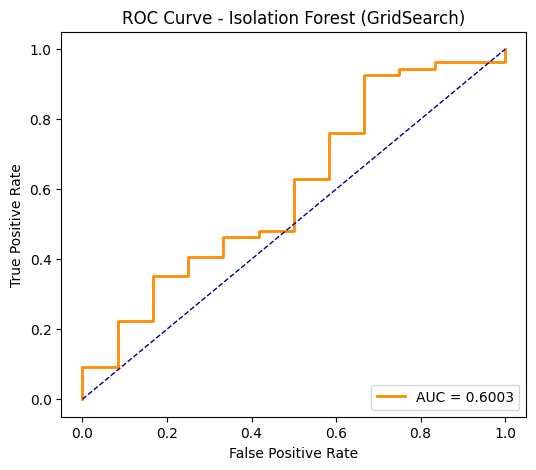

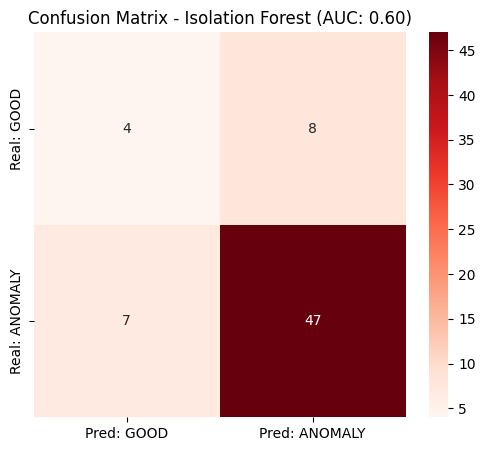

/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
2026/04/26 16:37:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saving model to MLFlow...
Model saved.


/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, balanced_accuracy_score
from mlflow.models import infer_signature
from sklearn.preprocessing import StandardScaler

#### --- INIT MLFLOW SERVICE --- ####
if MLFLOW_TRACKING_iFOREST:

    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=RUN_NAME):

        #### --- GRIDSEARCH + TRAIN MODEL (Isolation Forest) --- ####
        print(f"\n --- GRIDSEARCH TRAINING THE MODEL: {HP_MODEL_NAME} ---")

        # Scale HOG features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_hog)
        X_val_scaled = scaler.transform(X_val_hog)
        X_test_scaled = scaler.transform(X_test_hog)

        # Grid to try (adjustable)
        GRID_N_ESTIMATORS = [50, 100, 200]
        GRID_CONTAMINATION = [0.01, 0.02, 0.05, 'auto']

        grid_results = []

        for n in GRID_N_ESTIMATORS:
            for cont in GRID_CONTAMINATION:
                print(f"Evaluating n_estimators={n}, contamination={cont}")
                model = IsolationForest(n_estimators=n, contamination=cont, random_state=42, n_jobs=-1)
                model.fit(X_train_scaled)

                # Validation scores
                val_scores = model.decision_function(X_val_scaled)

                # Try to get threshold by target recall
                precision, recall, thresholds = precision_recall_curve(y_val, -val_scores)
                try:
                    idxs = np.where(recall >= HP_TARGET_RECALL)[0]
                    if len(idxs) > 0:
                        idx = idxs[-1]
                        best_threshold = -thresholds[idx]
                        method = 'target_recall'
                    else:
                        raise IndexError
                except Exception:
                    # fallback maximize F1 over candidate thresholds
                    f1s = []
                    thr_candidates = np.concatenate(([np.percentile(val_scores, p) for p in range(1,100,2)], thresholds))
                    thr_candidates = np.unique(thr_candidates)
                    for thr in thr_candidates:
                        y_val_pred = np.where(val_scores < thr, 1, 0)
                        f1s.append(f1_score(y_val, y_val_pred, zero_division=0))
                    best_idx = np.nanargmax(f1s)
                    best_threshold = thr_candidates[best_idx]
                    method = 'max_f1'

                y_val_pred = np.where(val_scores < best_threshold, 1, 0)
                val_report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
                val_macro_f1 = val_report['macro avg']['f1-score']
                val_balanced = balanced_accuracy_score(y_val, y_val_pred)

                grid_results.append({
                    'n_estimators': n,
                    'contamination': cont,
                    'threshold': float(best_threshold),
                    'method': method,
                    'val_macro_f1': float(val_macro_f1),
                    'val_balanced_acc': float(val_balanced)
                })

        # Choose best candidate
        grid_df = sorted(grid_results, key=lambda r: (r['val_macro_f1'], r['val_balanced_acc']), reverse=True)
        best = grid_df[0]

        print(f"Best IF candidate: n_estimators={best['n_estimators']}, contamination={best['contamination']}, threshold={best['threshold']:.6f}, method={best['method']}")

        # Refit best model
        best_model = IsolationForest(n_estimators=best['n_estimators'], contamination=best['contamination'], random_state=42, n_jobs=-1)
        best_model.fit(X_train_scaled)
        tuned_model = TunedIsolationForest(best_model, best['threshold'])

        # Log chosen params
        mlflow.log_param('if_grid_n_estimators', GRID_N_ESTIMATORS)
        mlflow.log_param('if_grid_contamination', GRID_CONTAMINATION)
        mlflow.log_param('if_chosen_n_estimators', best['n_estimators'])
        mlflow.log_param('if_chosen_contamination', str(best['contamination']))
        mlflow.log_param('if_chosen_threshold', best['threshold'])

        #### --- PREDICT TEST SET --- ####
        y_pred = tuned_model.predict(X_test_scaled)

        #### --- CLASSIFICATION REPORT --- ####
        print("\n --- CLASSIFICATION REPORT ---")
        report = classification_report(y_test, y_pred)
        report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        print(report)

        anomaly_scores = tuned_model.decision_function(X_test_scaled)
        auc_score = roc_auc_score(y_test, -anomaly_scores)
        print(f"ROC-AUC Score: {auc_score:.4f}")

        # Log metrics
        metrics_to_log = {
            'accuracy': report_dict.get('accuracy', 0.0),
            'macro_avg_f1': report_dict.get('macro avg', {}).get('f1-score', 0.0),
            'anomaly_recall': report_dict.get('1', {}).get('recall', 0.0),
            'anomaly_precision': report_dict.get('1', {}).get('precision', 0.0),
            'anomaly_f1': report_dict.get('1', {}).get('f1-score', 0.0),
            'good_recall': report_dict.get('0', {}).get('recall', 0.0),
            'roc_auc': auc_score
        }
        mlflow.log_metrics(metrics_to_log)

        # ROC and CM artifacts
        fpr, tpr, _ = roc_curve(y_test, -anomaly_scores)
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {auc_score:.4f}")
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title('ROC Curve - Isolation Forest (GridSearch)')
        ax_roc.legend(loc='lower right')
        roc_temp_path = 'reports/figures/roc_isolation_forest_grid.png'
        fig_roc.savefig(roc_temp_path)
        mlflow.log_artifact(roc_temp_path)
        os.remove(roc_temp_path)
        plt.show()

        cm = confusion_matrix(y_test, y_pred)
        fig_cm, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Pred: GOOD','Pred: ANOMALY'], yticklabels=['Real: GOOD','Real: ANOMALY'], ax=ax)
        ax.set_title(f"Confusion Matrix - Isolation Forest (AUC: {auc_score:.2f})")
        cm_temp_path = 'reports/figures/cm_isolation_forest_grid.png'
        fig_cm.savefig(cm_temp_path)
        mlflow.log_artifact(cm_temp_path)
        os.remove(cm_temp_path)
        plt.show()

        # Save pipeline
        if SAVE_MODEL_TO_MLFLOW:
            print('Saving model to MLFlow...')
            pipeline_final = Pipeline([('scaler', scaler), ('if_model', tuned_model)])
            y_pred_pipeline = pipeline_final.predict(X_test_hog)
            signature = infer_signature(X_test_hog, y_pred_pipeline)
            input_example = X_train_hog[:5]
            mlflow.sklearn.log_model(pipeline_final, 'isolation_forest_gridsearched', signature=signature, input_example=input_example)
            print('Model saved.')

### One-Class SVM (OC-SVM): Model Description

**1. What is it?**
The One-Class Support Vector Machine (OC-SVM) is a variation of the classic SVM designed specifically for **unsupervised anomaly detection**. Unlike a standard SVM that tries to separate two different classes (e.g., Cats vs. Dogs), the OC-SVM is trained on only **one class** of data: the "Normal" class. Its goal is to learn the boundaries of what "Normal" looks like to identify anything that doesn't fit that description.

**2. How does it work?**
Instead of building a "wide street" to separate two groups, think of OC-SVM as wrapping a **tight elastic band** (or a sphere) around the training data.
* **The Boundary:** The algorithm tries to find the smallest possible region (hypersphere) that contains most of the training data points (the "Good" capsules).
* **The Kernel Trick:** It uses a mathematical trick (usually the **RBF Kernel**) to project the data into higher dimensions. This allows it to create complex, non-linear boundaries that hug the shape of the data distribution, rather than just drawing a simple circle.
* **The Decision:** Once trained, if a new data point falls *inside* this boundary, it is classified as **Normal**. If it falls *outside*, it is classified as an **Anomaly**.

**3. Why use it for MVTec Capsules?**
* **Training Constraints:** We only have images of "Good" capsules for training. OC-SVM is built exactly for this "Novelty Detection" scenario.
* **High-Dimensional Complexity:** HOG features create a complex data space. OC-SVM is powerful because it uses kernels to handle these complex relationships, defining a very specific "shape" of normality for the capsules. Anything that deviates from this specific texture or shape (like a scratch) will likely fall outside the boundary.

In [11]:
from sklearn.base import BaseEstimator, OutlierMixin

#### --- MODEL OC-SVM TUNING ONCE TRAINED --- ####
class TunedOCSVM(BaseEstimator, OutlierMixin): # Sklearn-anomaly-detection model
    def __init__(self, base_model, threshold):
        self.base_model = base_model # OC-SVM model trained
        self.threshold = threshold #  Best threshold

    def fit(self, X, y=None): # Model trained already; no labels needed
        return self
    
    def predict(self, X):
        # Get raw scores:
        scores = self.base_model.decision_function(X)

        # Apply optimized threshold:
        return np.where(scores < self.threshold, 1, 0)
    
    def decision_function(self, X):
        return self.base_model.decision_function(X)

In [12]:
#### --- PARAMTERS --- ####
MLFLOW_TRACKING_OCSVM = True
RUN_NAME = "Try: OC-SVM model with PCA and Threshold tuning - changing the target recall"
SAVE_MODEL_TO_MLFLOW = True

if SAVE_MODEL_TO_MLFLOW:
    RUN_NAME = RUN_NAME
else:
    RUN_NAME = f"{RUN_NAME} - NO model saved"

# Hyperparameters:
HP_MODEL_NAME = "OC-SVM_optimized"
HP_FEATURES = "HOG"
HP_NU = 0.05 # Tolerance to errors
HP_KERNEL = 'rbf'
HP_GAMMA = 'scale' # Sphere-to-data adjusting
HP_PCA_VARIANCE = 0.95 # Keep 95% percent of information in PCA
HP_TARGET_RECALL = 0.98


 --- GRIDSEARCH TRAINING THE MODEL: OC-SVM_optimized ---
Evaluating nu=0.01, gamma=scale, pca_var=0.9
Evaluating nu=0.01, gamma=scale, pca_var=0.95
Evaluating nu=0.01, gamma=scale, pca_var=0.98
Evaluating nu=0.01, gamma=auto, pca_var=0.9
Evaluating nu=0.01, gamma=auto, pca_var=0.95
Evaluating nu=0.01, gamma=auto, pca_var=0.98
Evaluating nu=0.03, gamma=scale, pca_var=0.9
Evaluating nu=0.03, gamma=scale, pca_var=0.95
Evaluating nu=0.03, gamma=scale, pca_var=0.98
Evaluating nu=0.03, gamma=auto, pca_var=0.9
Evaluating nu=0.03, gamma=auto, pca_var=0.95
Evaluating nu=0.03, gamma=auto, pca_var=0.98
Evaluating nu=0.05, gamma=scale, pca_var=0.9
Evaluating nu=0.05, gamma=scale, pca_var=0.95
Evaluating nu=0.05, gamma=scale, pca_var=0.98
Evaluating nu=0.05, gamma=auto, pca_var=0.9
Evaluating nu=0.05, gamma=auto, pca_var=0.95
Evaluating nu=0.05, gamma=auto, pca_var=0.98
Evaluating nu=0.1, gamma=scale, pca_var=0.9
Evaluating nu=0.1, gamma=scale, pca_var=0.95
Evaluating nu=0.1, gamma=scale, pca_var=

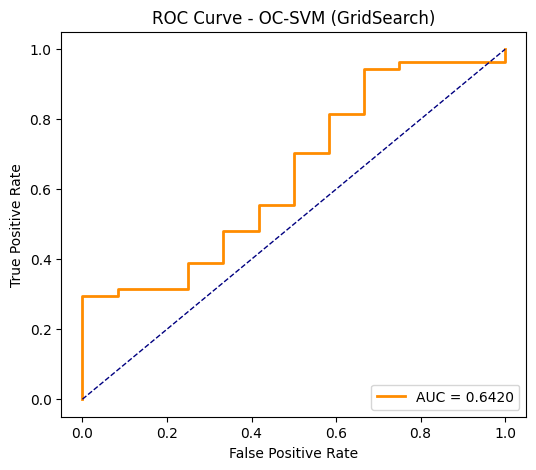

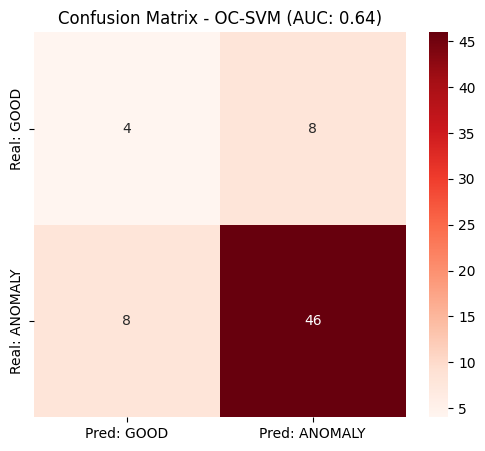

2026/04/26 16:38:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saving model to MLFlow...
Model saved.


In [13]:
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve, f1_score, balanced_accuracy_score
from mlflow.models import infer_signature

#### --- INIT MLFLOW SERVICE --- ####
if MLFLOW_TRACKING_OCSVM:

    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=RUN_NAME):

        #### --- GRIDSEARCH + TRAIN MODEL (OC-SVM) --- ####
        print(f"\n --- GRIDSEARCH TRAINING THE MODEL: {HP_MODEL_NAME} ---")

        # Grid definitions
        GRID_NU = [0.01, 0.03, 0.05, 0.1]
        GRID_GAMMA = ['scale', 'auto']
        GRID_PCA_VARIANCE = [0.90, 0.95, 0.98]

        grid_results = []

        for nu in GRID_NU:
            for gamma in GRID_GAMMA:
                for pvar in GRID_PCA_VARIANCE:
                    print(f"Evaluating nu={nu}, gamma={gamma}, pca_var={pvar}")

                    pipeline = Pipeline(steps=[
                        ('scaler', StandardScaler()),
                        ('pca', PCA(n_components=pvar)),
                        ('model', OneClassSVM(kernel=HP_KERNEL, gamma=gamma, nu=nu))
                    ])

                    pipeline.fit(X_train_hog)

                    # Validation scores
                    val_scores = pipeline.decision_function(X_val_hog)

                    # Threshold selection
                    precision, recall, thresholds = precision_recall_curve(y_val, -val_scores)
                    try:
                        idxs = np.where(recall >= HP_TARGET_RECALL)[0]
                        if len(idxs) > 0:
                            idx = idxs[-1]
                            best_threshold = -thresholds[idx]
                            method = 'target_recall'
                        else:
                            raise IndexError
                    except Exception:
                        f1s = []
                        thr_candidates = np.concatenate(([np.percentile(val_scores, p) for p in range(1,100,2)], thresholds))
                        thr_candidates = np.unique(thr_candidates)
                        for thr in thr_candidates:
                            y_val_pred = np.where(val_scores < thr, 1, 0)
                            f1s.append(f1_score(y_val, y_val_pred, zero_division=0))
                        best_idx = np.nanargmax(f1s)
                        best_threshold = thr_candidates[best_idx]
                        method = 'max_f1'

                    y_val_pred = np.where(val_scores < best_threshold, 1, 0)
                    val_report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
                    val_macro_f1 = val_report['macro avg']['f1-score']
                    val_balanced = balanced_accuracy_score(y_val, y_val_pred)

                    grid_results.append({
                        'nu': nu,
                        'gamma': gamma,
                        'pca_variance': pvar,
                        'threshold': float(best_threshold),
                        'method': method,
                        'val_macro_f1': float(val_macro_f1),
                        'val_balanced_acc': float(val_balanced),
                        'n_components': int(pipeline.named_steps['pca'].n_components_)
                    })

        # Select best
        grid_df = sorted(grid_results, key=lambda r: (r['val_macro_f1'], r['val_balanced_acc']), reverse=True)
        best = grid_df[0]
        print(f"Best OC-SVM candidate: nu={best['nu']}, gamma={best['gamma']}, pca_var={best['pca_variance']}, threshold={best['threshold']:.6f}, n_components={best['n_components']}")

        # Refit best pipeline
        pipeline_best = Pipeline(steps=[
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=best['pca_variance'])),
            ('model', OneClassSVM(kernel=HP_KERNEL, gamma=best['gamma'], nu=best['nu']))
        ])
        pipeline_best.fit(X_train_hog)

        model_optimized = TunedOCSVM(pipeline_best, best['threshold'])

        # Log chosen params
        mlflow.log_param('ocsvm_grid_nu', GRID_NU)
        mlflow.log_param('ocsvm_grid_gamma', GRID_GAMMA)
        mlflow.log_param('ocsvm_grid_pca', GRID_PCA_VARIANCE)
        mlflow.log_param('ocsvm_chosen_nu', best['nu'])
        mlflow.log_param('ocsvm_chosen_gamma', best['gamma'])
        mlflow.log_param('ocsvm_chosen_pca_variance', best['pca_variance'])
        mlflow.log_param('ocsvm_chosen_threshold', best['threshold'])

        #### --- PREDICT TEST SET --- ####
        y_pred = model_optimized.predict(X_test_hog)

        #### --- CLASSIFICATION REPORT --- ####
        print("\n --- CLASSIFICATION REPORT ---")
        report = classification_report(y_test, y_pred)
        report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        print(report)

        anomaly_scores = model_optimized.decision_function(X_test_hog)
        auc_score = roc_auc_score(y_test, -anomaly_scores)
        print(f"ROC-AUC Score: {auc_score:.4f}")

        # Log metrics
        metrics_to_log = {
            'accuracy': report_dict.get('accuracy', 0.0),
            'macro_avg_f1': report_dict.get('macro avg', {}).get('f1-score', 0.0),
            'anomaly_recall': report_dict.get('1', {}).get('recall', 0.0),
            'anomaly_precision': report_dict.get('1', {}).get('precision', 0.0),
            'anomaly_f1': report_dict.get('1', {}).get('f1-score', 0.0),
            'good_recall': report_dict.get('0', {}).get('recall', 0.0),
            'roc_auc': auc_score
        }
        mlflow.log_metrics(metrics_to_log)

        # ROC and CM artifacts
        fpr, tpr, _ = roc_curve(y_test, -anomaly_scores)
        fig_roc, ax_roc = plt.subplots(figsize=(6,5))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {auc_score:.4f}")
        ax_roc.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title('ROC Curve - OC-SVM (GridSearch)')
        ax_roc.legend(loc='lower right')
        roc_temp_path = 'reports/figures/roc_oc_svm_grid.png'
        fig_roc.savefig(roc_temp_path)
        mlflow.log_artifact(roc_temp_path)
        os.remove(roc_temp_path)
        plt.show()

        cm = confusion_matrix(y_test, y_pred)
        fig_cm, ax = plt.subplots(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Pred: GOOD','Pred: ANOMALY'], yticklabels=['Real: GOOD','Real: ANOMALY'], ax=ax)
        ax.set_title(f"Confusion Matrix - OC-SVM (AUC: {auc_score:.2f})")
        cm_temp_path = 'reports/figures/cm_oc_svm_grid.png'
        fig_cm.savefig(cm_temp_path)
        mlflow.log_artifact(cm_temp_path)
        os.remove(cm_temp_path)
        plt.show()

        # Save pipeline
        if SAVE_MODEL_TO_MLFLOW:
            print('Saving model to MLFlow...')
            mlflow.sklearn.log_model(model_optimized, 'ocsvm_gridsearched', signature=infer_signature(X_test_hog, model_optimized.predict(X_test_hog)), input_example=X_train_hog[:5])
            print('Model saved.')

### PCA Reconstruction Error: Model Description

**1. What is it?**
Principal Component Analysis (PCA) is traditionally used for dimensionality reduction. However, in the context of **Anomaly Detection**, it is used as a **reconstruction-based model**. The core idea is that a PCA model trained only on "Normal" data learns to compress and reconstruct normal patterns efficiently, but fails to reconstruct anomalies accurately.

**2. How does it work?**
* **Compression (Encoding):** The model projects the high-dimensional input data (HOG features) into a lower-dimensional space using the principal components that capture the most variance of the "Good" capsules.
* **Reconstruction (Decoding):** The model attempts to reconstruct the original data back from this compressed representation.
* **The Anomaly Score:** The system calculates the **Reconstruction Error** (usually Mean Squared Error) between the original input and the reconstructed output.
    * **Normal Capsule:** The error is low because the PCA components capture its structure well.
    * **Defective Capsule:** The defect (e.g., a crack) represents "variance" that was never seen during training. PCA drops this information during compression, so the reconstruction fails to reproduce the defect, resulting in a **high reconstruction error**.

**3. Why use it for MVTec Capsules?**
* **Global Structure Sensitivity:** PCA captures the global correlation of the HOG features. Since capsules are rigid objects with a fixed structure, PCA creates a very strong model of what a "valid" capsule shape looks like.
* **Sensitivity to Breaks:** Defects like cracks or large scratches break the global correlations of the image gradients. PCA is particularly bad at reconstructing these "outlier" features, making the error signal very strong and distinct for detection.

In [14]:
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.decomposition import PCA

#### --- MODEL PCA RECONSTRUCTION ERROR --- ####
class PCADetector(BaseEstimator, OutlierMixin): # Sklearn-anomaly-detection model
    def __init__(self, n_components=None, threshold=None):
        self.n_components = n_components
        self.threshold = threshold #  Best threshold
        self.pca = None

    def fit(self, X, y=None): # Standard PCA trained already
        self.pca = PCA(n_components=self.n_components)
        self.pca.fit(X)

        return self
    
    def decision_function(self, X):
        X_reduced = self.pca.transform(X) # ENCODING
        X_reconstructed = self.pca.inverse_transform(X_reduced) # DECODING

        # High score = GOOD | Low score = ANOMALY
        reconstruction_error = np.mean((X - X_reconstructed) **2, axis=1) # MSE

        return -reconstruction_error # Inverse logic: (return negative)
    
    def predict(self, X):
        # Get raw scores:
        scores = self.decision_function(X)

        if self.threshold is not None:
            
            return np.where(scores < self.threshold, 1, 0)
        
        return scores

In [15]:
#### --- PARAMTERS --- ####
MLFLOW_TRACKING_PCA_RE = True
RUN_NAME = "Try: Base-Line (PCA-RE model)"
SAVE_MODEL_TO_MLFLOW = True

if SAVE_MODEL_TO_MLFLOW:
    RUN_NAME = RUN_NAME
else:
    RUN_NAME = f"{RUN_NAME} - NO model saved"

# Hyperparameters:
HP_MODEL_NAME = "pca_reconstruction"
HP_FEATURES = "HOG"
HP_PCA_VARIANCE = 0.95 # Keep 95% percent of information in PCA
HP_TARGET_RECALL = 0.98


 --- GRIDSEARCH TRAINING THE MODEL: pca_reconstruction ---
Evaluating PCA variance=0.9
Evaluating PCA variance=0.92
Evaluating PCA variance=0.94
Evaluating PCA variance=0.95
Evaluating PCA variance=0.96
Evaluating PCA variance=0.98
Best candidate: PCA variance=0.98 (n_components=209) - threshold=-0.826677 - method=target_recall

 --- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0       0.42      0.42      0.42        12
           1       0.87      0.87      0.87        54

    accuracy                           0.79        66
   macro avg       0.64      0.64      0.64        66
weighted avg       0.79      0.79      0.79        66

ROC-AUC Score: 0.8117
Recording metrics to MLFlow...


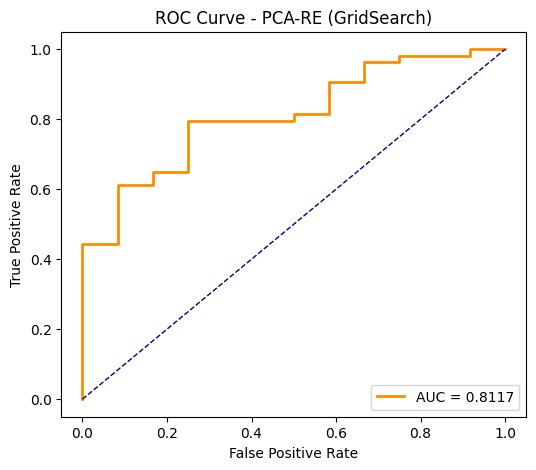

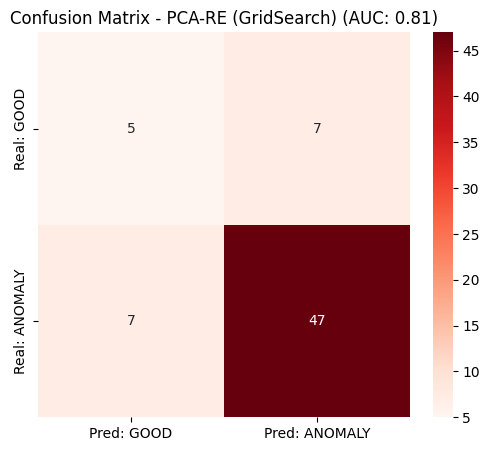

/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
2026/04/26 16:38:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saving model to MLFlow...
Model saved.


/opt/homebrew/Caskroom/miniforge/base/envs/mlEnv/lib/python3.10/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, roc_curve, f1_score, balanced_accuracy_score
from mlflow.models import infer_signature

#### --- INIT MLFLOW SERVICE --- ####
if MLFLOW_TRACKING_PCA_RE:

    mlflow.set_experiment(EXPERIMENT_NAME)

    with mlflow.start_run(run_name=RUN_NAME):

        #### --- TRAIN + GRIDSEARCH MODEL --- ####
        print(f"\n --- GRIDSEARCH TRAINING THE MODEL: {HP_MODEL_NAME} ---")

        # Escaling the data:
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_hog)
        X_val_scaled = scaler.transform(X_val_hog)
        X_test_scaled = scaler.transform(X_test_hog)

        # Grid of PCA variance ratios to try (can be adjusted):
        HP_PCA_GRID = [0.90, 0.92, 0.94, 0.95, 0.96, 0.98]

        grid_results = []

        for cand in HP_PCA_GRID:
            print(f"Evaluating PCA variance={cand}")

            # Fit PCA detector on training data only
            candidate = PCADetector(n_components=cand)
            candidate.fit(X_train_scaled)

            # Validation scores (higher = GOOD, lower = anomaly due to negative reconstruction error)
            val_scores = candidate.decision_function(X_val_scaled)

            # Precision-Recall based thresholding to meet target recall if possible
            precision, recall, thresholds = precision_recall_curve(y_val, -val_scores)

            try:
                idxs = np.where(recall >= HP_TARGET_RECALL)[0]
                if len(idxs) > 0:
                    idx = idxs[-1]
                    best_threshold = -thresholds[idx]
                    method = 'target_recall'
                else:
                    raise IndexError
            except Exception:
                # Fallback: choose threshold that maximizes F1 on validation
                f1s = []
                thr_candidates = np.concatenate(([np.percentile(val_scores, p) for p in range(1,100,2)], thresholds))
                thr_candidates = np.unique(thr_candidates)
                for thr in thr_candidates:
                    y_val_pred = np.where(val_scores < thr, 1, 0)
                    f1s.append(f1_score(y_val, y_val_pred, zero_division=0))
                best_idx = np.nanargmax(f1s)
                best_threshold = thr_candidates[best_idx]
                method = 'max_f1'

            # Evaluate candidate on validation with chosen threshold
            y_val_pred = np.where(val_scores < best_threshold, 1, 0)
            val_report = classification_report(y_val, y_val_pred, output_dict=True, zero_division=0)
            val_macro_f1 = val_report['macro avg']['f1-score']
            val_balanced = balanced_accuracy_score(y_val, y_val_pred)

            grid_results.append({
                'pca_variance': cand,
                'threshold': float(best_threshold),
                'method': method,
                'val_macro_f1': float(val_macro_f1),
                'val_balanced_acc': float(val_balanced),
                'n_components': int(candidate.pca.n_components_)
            })

        # Choose best candidate (by val_macro_f1, then balanced acc)
        grid_df = sorted(grid_results, key=lambda r: (r['val_macro_f1'], r['val_balanced_acc']), reverse=True)
        best = grid_df[0]

        print(f"Best candidate: PCA variance={best['pca_variance']} (n_components={best['n_components']}) - threshold={best['threshold']:.6f} - method={best['method']}")

        # Re-fit best model to get final detector object
        pca_re_model = PCADetector(n_components=best['pca_variance'])
        pca_re_model.fit(X_train_scaled)
        pca_re_model.threshold = best['threshold']

        # Log grid results to MLFlow
        mlflow.log_param('pca_grid', HP_PCA_GRID)
        mlflow.log_param('chosen_pca_variance', best['pca_variance'])
        mlflow.log_param('chosen_n_components', best['n_components'])
        mlflow.log_param('chosen_threshold', best['threshold'])

        #### --- PREDICT TEST SET WITH BEST MODEL --- ####
        y_pred = pca_re_model.predict(X_test_scaled)

        #### --- CLASSIFICATION REPORT --- ####
        print("\n --- CLASSIFICATION REPORT ---")
        report = classification_report(y_test, y_pred)
        report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        print(report)

        anomaly_scores = pca_re_model.decision_function(X_test_scaled)
        auc_score = roc_auc_score(y_test, -anomaly_scores)
        print(f"ROC-AUC Score: {auc_score:.4f}")

        # Record metrics to MLFlow:
        print("Recording metrics to MLFlow...")
        metrics_to_log = {
            "accuracy": report_dict.get("accuracy", 0.0),
            "macro_avg_f1": report_dict.get("macro avg", {}).get("f1-score", 0.0),
            "anomaly_recall": report_dict.get('1', {}).get('recall', 0.0),
            "anomaly_precision": report_dict.get('1', {}).get('precision', 0.0),
            "anomaly_f1": report_dict.get('1', {}).get('f1-score', 0.0),
            "good_recall": report_dict.get('0', {}).get('recall', 0.0),
            "roc_auc": auc_score,
        }
        mlflow.log_metrics(metrics_to_log)

        #### --- ROC CURVE --- ####
        fpr, tpr, _ = roc_curve(y_test, -anomaly_scores)
        fig_roc, ax_roc = plt.subplots(figsize=(6, 5))
        ax_roc.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {auc_score:.4f}")
        ax_roc.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
        ax_roc.set_xlabel('False Positive Rate')
        ax_roc.set_ylabel('True Positive Rate')
        ax_roc.set_title('ROC Curve - PCA-RE (GridSearch)')
        ax_roc.legend(loc='lower right')
        roc_temp_path = "reports/figures/roc_pca_re_grid.png"
        fig_roc.savefig(roc_temp_path)
        mlflow.log_artifact(roc_temp_path)
        os.remove(roc_temp_path)
        plt.show()

        #### --- CONFUSION MATRIX --- ###
        cm = confusion_matrix(y_test, y_pred)
        fig_cm, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Pred: GOOD', 'Pred: ANOMALY'],
            yticklabels=['Real: GOOD', 'Real: ANOMALY'], ax=ax)
        ax.set_title(f"Confusion Matrix - PCA-RE (GridSearch) (AUC: {auc_score:.2f})")

        cm_temp_path = "reports/figures/cm_pca_re_grid.png"
        fig_cm.savefig(cm_temp_path)
        mlflow.log_artifact(cm_temp_path)
        os.remove(cm_temp_path)

        plt.show()
        plt.close()

        #### --- SAVE MODEL --- ####
        if SAVE_MODEL_TO_MLFLOW:
            print("Saving model to MLFlow...")
            # Save full pipeline (Scaler + Detector) for production use with raw HOG input.
            pipeline_final = Pipeline([
                ('scaler', scaler),
                ('pca_detector', pca_re_model)
            ])

            y_pred_pipeline = pipeline_final.predict(X_test_hog)
            signature = infer_signature(X_test_hog, y_pred_pipeline)
            input_example = X_train_hog[:5]

            mlflow.sklearn.log_model(
                pipeline_final,
                "pca_reconstruction_model_gridsearched",
                signature=signature,
                input_example=input_example
            )
            print("Model saved.")